In [13]:
#Importing Required Libraries
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import matplotlib.pyplot as plt

In [14]:
# Load the dataset
df = pd.read_csv("breastcancer.csv")
# Display the first 5 rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [15]:
# Remove unwanted columns
df = df.drop(columns=["id", "Unnamed: 32"])

# Convert diagnosis column
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
#Features and Target
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

In [17]:
#Splitting the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
#Training the Model
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [19]:
#Predicting data
y_pred = model.predict(X_test)
print(y_pred)

[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1]


[[70  1]
 [ 4 39]]


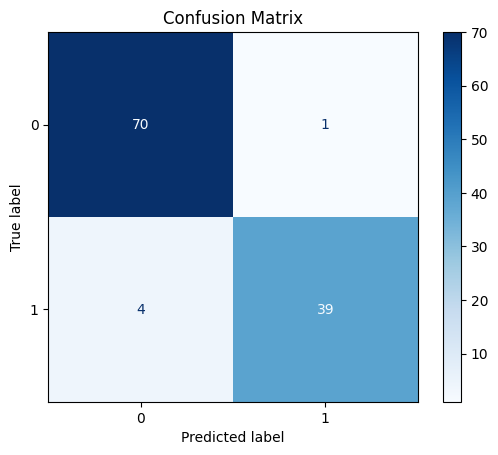

In [20]:
#Dsiplaying Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [21]:
#Accuracy, Precision & Recall
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Accuracy : 0.956140350877193
Precision : 0.975
Recall : 0.9069767441860465
F1 Score : 0.9397590361445783


In [22]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [23]:
#Cross Validation(5-fold)
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")

print(scores)

print("Mean Accuracy:", scores.mean())

Cross Validation Scores:
[0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Mean Accuracy: 0.9507995652848935


In [24]:
#Compare Accuracy With Validation
print("Test Accuracy :", accuracy)

print("Cross Validation Mean Accuracy :", scores.mean())

difference = abs(accuracy - scores.mean())

if accuracy >= 0.95 and difference < 0.03:
    print("Model Status : Best")
    print("Reason : High accuracy and consistent cross-validation performance.")

elif accuracy >= 0.85:
    print("Model Status : Good")
    print("Reason : Good performance with acceptable consistency.")

else:
    print("Model Status : Needs Improvement")
    print("Reason : Accuracy is low or varies significantly from cross-validation.")

Test Accuracy : 0.956140350877193
Cross Validation Mean Accuracy : 0.9507995652848935
Model Status : Best
Reason : High accuracy and consistent cross-validation performance.
